# Big Data Lab 3 — Spark Local: Joins, Shuffles, Skew

**Apache Spark** is a distributed data processing engine used for large-scale ETL and analytics. In Colab we run Spark in **local mode** (`local[*]`), so everything runs on one machine — but Spark still builds the same kinds of execution plans you’d see on a cluster. This lab focuses on the core mental model: partitions, shuffles, join strategies, and why data skew can break performance.

## What you’ll do (end-to-end)
- Start a local Spark session (in Colab).
- Read Parquet data and run a few transformations.
- Understand when Spark does a **shuffle** (and why it’s expensive).
- Compare join strategies (shuffle join vs broadcast join).
- Create a **skewed** dataset, observe the problem, and apply a mitigation.

## Why this matters
Even without a cluster, Spark teaches “distributed thinking”:
- how work is split into partitions,
- why shuffles dominate runtime,
- why a single hot key can stall an entire job.

## Evaluation
50% correctness/completion + 50% explanation.
Be ready to explain: partitions, shuffle, broadcast join, skew, and mitigation tradeoffs.


## Concepts cheat sheet (read once)

- `partition`: a chunk of a dataset processed by one task. More partitions -> more parallelism (up to your cores).
- `join`: combines two tables by a key. In Spark, a join can be expensive because it may require moving rows across the network (a shuffle).
- `broadcast join`: ship a small table to every worker and join locally. Avoids shuffling the big table. Good when one side is tiny.
- `shuffle`: Spark redistributes rows across partitions based on a key (for joins/groupBy/orderBy/distinct). It’s expensive due to disk + network.
- `Exchange` (in `explain()`): a strong hint a shuffle happens.
- `skew`: one key (or a few) has way more rows than others, so one task/partition becomes a bottleneck.
- `salting`: split a hot key into multiple keys (key + salt) to spread work across partitions; increases complexity and can enlarge dimensions.


## Setup (run once)
We use PySpark in local mode. This is not a long-running service; it fits Colab well.


In [1]:
!pip -q install pyspark matplotlib

import time
import math
import shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

print("Imports OK")


Imports OK


## Optional: Persist outputs in Google Drive


In [2]:
USE_DRIVE = False  # <- change to True to persist outputs in Google Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/BDLab/Lab3")
else:
    BASE_DIR = Path("/content/BDLab/Lab3")

RAW_DIR = BASE_DIR / "raw"
OUT_DIR = BASE_DIR / "out"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_DIR


PosixPath('/content/BDLab/Lab3')

## 1) Start Spark
We use a small number of shuffle partitions to make behavior easier to see.


In [3]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BDLab3")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))


Spark version: 4.0.2
shuffle partitions: 8


## 2) Download a real dataset (NYC Taxi trips) + a small dimension table
We will:
- download one Parquet month,
- slice the first 7 days,
- join to a small taxi-zone lookup table.

This keeps continuity with Labs 1–2 (same domain, same columns).


In [4]:
YEAR = 2024
MONTH = 1
START_DAY = 1
END_DAY_EXCL = 8

trips_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{YEAR}-{MONTH:02d}.parquet"
trips_path = RAW_DIR / f"yellow_tripdata_{YEAR}-{MONTH:02d}.parquet"

zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zone_path = RAW_DIR / "taxi_zone_lookup.csv"

if not trips_path.exists():
    print("Downloading trips:", trips_url)
    !wget -q "{trips_url}" -O "{trips_path}"
else:
    print("Already downloaded trips:", trips_path)

if not zone_path.exists():
    print("Downloading zone lookup:", zone_url)
    !wget -q "{zone_url}" -O "{zone_path}"
else:
    print("Already downloaded zone lookup:", zone_path)

trips_path, zone_path


(PosixPath('/content/BDLab/Lab3/raw/yellow_tripdata_2024-01.parquet'),
 PosixPath('/content/BDLab/Lab3/raw/taxi_zone_lookup.csv'))

## 3) Read Parquet into Spark + build a clean-ish DataFrame
We keep a practical subset of columns and add `pickup_date`.


In [5]:
start_date = f"{YEAR}-{MONTH:02d}-{START_DAY:02d}"
end_date = f"{YEAR}-{MONTH:02d}-{END_DAY_EXCL:02d}"  # exclusive

trips_raw = spark.read.parquet(str(trips_path))

trips = (
    trips_raw
    .select(
        F.col("tpep_pickup_datetime"),
        F.col("tpep_dropoff_datetime"),
        F.col("PULocationID"),
        F.col("DOLocationID"),
        F.col("passenger_count"),
        F.col("trip_distance"),
        F.col("total_amount"),
    )
    .withColumn("pickup_date", F.to_date("tpep_pickup_datetime"))
    .where(F.col("tpep_pickup_datetime") >= F.to_timestamp(F.lit(start_date)))
    .where(F.col("tpep_pickup_datetime") <  F.to_timestamp(F.lit(end_date)))
    .where(F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime"))
    .where(F.col("trip_distance") >= 0)
    .where(F.col("total_amount") >= 0)
)

print("Rows (week slice):", trips.count())
print("Partitions:", trips.rdd.getNumPartitions())
trips.limit(5).toPandas()


Rows (week slice): 601505
Partitions: 2


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,total_amount,pickup_date
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,1,1.72,22.70,2024-01-01
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1,1.80,18.75,2024-01-01
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1,4.70,31.30,2024-01-01
3,2024-01-01 00:36:38,2024-01-01 00:44:56,79,211,1,1.40,17.00,2024-01-01
4,2024-01-01 00:46:51,2024-01-01 00:52:57,211,148,1,0.80,16.10,2024-01-01


## 4) Read the zone lookup dimension
This table is tiny (hundreds of rows). It’s a perfect broadcast candidate.


In [6]:
zones = (
    spark.read
    .option("header", True)
    .csv(str(zone_path))
    .select(
        F.col("LocationID").cast("int").alias("PULocationID"),
        F.col("Borough").alias("pickup_borough"),
        F.col("Zone").alias("pickup_zone"),
    )
)

print("zones rows:", zones.count())
zones.orderBy("PULocationID").limit(5).toPandas()


zones rows: 265


,PULocationID,pickup_borough,pickup_zone
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights


## 5) Shuffle join vs broadcast join
We disable auto-broadcast so the *default* join is a shuffle join.
Then we force a broadcast join and compare the plans.


In [7]:
# Disable auto-broadcast to make the difference obvious.
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)
print("autoBroadcastJoinThreshold:", spark.conf.get("spark.sql.autoBroadcastJoinThreshold"))

joined_shuffle = trips.join(zones, on="PULocationID", how="left")

print("Plan (shuffle join expected):")
joined_shuffle.explain("formatted")


autoBroadcastJoinThreshold: -1
Plan (shuffle join expected):
== Physical Plan ==
AdaptiveSparkPlan (13)
+- Project (12)
   +- SortMergeJoin LeftOuter (11)
      :- Sort (5)
      :  +- Exchange (4)
      :     +- Project (3)
      :        +- Filter (2)
      :           +- Scan parquet  (1)
      +- Sort (10)
         +- Exchange (9)
            +- Project (8)
               +- Filter (7)
                  +- Scan csv  (6)


(1) Scan parquet 
Output [7]: [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, PULocationID#7, DOLocationID#8, total_amount#16]
Batched: true
Location: InMemoryFileIndex [file:/content/BDLab/Lab3/raw/yellow_tripdata_2024-01.parquet]
PushedFilters: [IsNotNull(tpep_pickup_datetime), IsNotNull(tpep_dropoff_datetime), IsNotNull(trip_distance), IsNotNull(total_amount), GreaterThanOrEqual(tpep_pickup_datetime,2024-01-01T00:00), LessThan(tpep_pickup_datetime,2024-01-08T00:00), GreaterThanOrEqual(trip_distance,0.0), GreaterThanOrEqual

In [8]:
# Force broadcast join (zones is tiny)
joined_broadcast = trips.join(F.broadcast(zones), on="PULocationID", how="left")

print("Plan (broadcast join expected):")
joined_broadcast.explain("formatted")


Plan (broadcast join expected):
== Physical Plan ==
AdaptiveSparkPlan (10)
+- Project (9)
   +- BroadcastHashJoin LeftOuter BuildRight (8)
      :- Project (3)
      :  +- Filter (2)
      :     +- Scan parquet  (1)
      +- BroadcastExchange (7)
         +- Project (6)
            +- Filter (5)
               +- Scan csv  (4)


(1) Scan parquet 
Output [7]: [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, PULocationID#7, DOLocationID#8, total_amount#16]
Batched: true
Location: InMemoryFileIndex [file:/content/BDLab/Lab3/raw/yellow_tripdata_2024-01.parquet]
PushedFilters: [IsNotNull(tpep_pickup_datetime), IsNotNull(tpep_dropoff_datetime), IsNotNull(trip_distance), IsNotNull(total_amount), GreaterThanOrEqual(tpep_pickup_datetime,2024-01-01T00:00), LessThan(tpep_pickup_datetime,2024-01-08T00:00), GreaterThanOrEqual(trip_distance,0.0), GreaterThanOrEqual(total_amount,0.0)]
ReadSchema: struct<tpep_pickup_datetime:timestamp_ntz,tpep_dropoff_datetime:tim

### Tiny exercise 1 (5–10 minutes)
Modify the code cell below so that the join uses a **broadcast join**.

Hints:
- Use `F.broadcast(zones)`.
- Verify the plan contains something like `BroadcastHashJoin`.


In [ ]:
# Tiny exercise 1
# Modify this cell so the join uses a BROADCAST join.
#
# Hints:
# - Use: trips.join(F.broadcast(zones), on="PULocationID", how="left")
# - Verify with: j.explain("formatted")

# TODO: create j as a broadcast join.

raise NotImplementedError("Exercise 1: force a broadcast join and verify the plan.")


## 6) What is a shuffle, operationally?
A shuffle is Spark moving data across partitions based on a key.

Common shuffle operations:
- `groupBy(...).agg(...)`
- joins on large tables (when not broadcast)
- `distinct`, `orderBy`, `repartition` by key

We’ll look for an `Exchange` operator in the plan and also visualize partition sizes.


In [9]:
# Helper: time an action (Spark is lazy)
def time_action(label: str, fn):
    t0 = time.perf_counter()
    out = fn()
    dt = time.perf_counter() - t0
    print(f"{label}: {dt:.3f}s")
    return out, dt

# Helper: count rows per partition (forces an action)
def partition_row_counts(df):
    rows = df.rdd.mapPartitionsWithIndex(lambda idx, it: [(idx, sum(1 for _ in it))]).collect()
    return pd.DataFrame(rows, columns=["partition", "rows"]).sort_values("partition")


In [10]:
# A groupBy triggers a shuffle.
per_day = trips.groupBy("pickup_date").agg(
    F.count("*").alias("trips"),
    F.avg("total_amount").alias("avg_total_amount"),
)

print("Plan (look for Exchange):")
per_day.explain("formatted")


Plan (look for Exchange):
== Physical Plan ==
AdaptiveSparkPlan (7)
+- HashAggregate (6)
   +- Exchange (5)
      +- HashAggregate (4)
         +- Project (3)
            +- Filter (2)
               +- Scan parquet  (1)


(1) Scan parquet 
Output [4]: [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, trip_distance#4, total_amount#16]
Batched: true
Location: InMemoryFileIndex [file:/content/BDLab/Lab3/raw/yellow_tripdata_2024-01.parquet]
PushedFilters: [IsNotNull(tpep_pickup_datetime), IsNotNull(tpep_dropoff_datetime), IsNotNull(trip_distance), IsNotNull(total_amount), GreaterThanOrEqual(tpep_pickup_datetime,2024-01-01T00:00), LessThan(tpep_pickup_datetime,2024-01-08T00:00), GreaterThanOrEqual(trip_distance,0.0), GreaterThanOrEqual(total_amount,0.0)]
ReadSchema: struct<tpep_pickup_datetime:timestamp_ntz,tpep_dropoff_datetime:timestamp_ntz,trip_distance:double,total_amount:double>

(2) Filter
Input [4]: [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, trip_distance#4, total_amount#16]


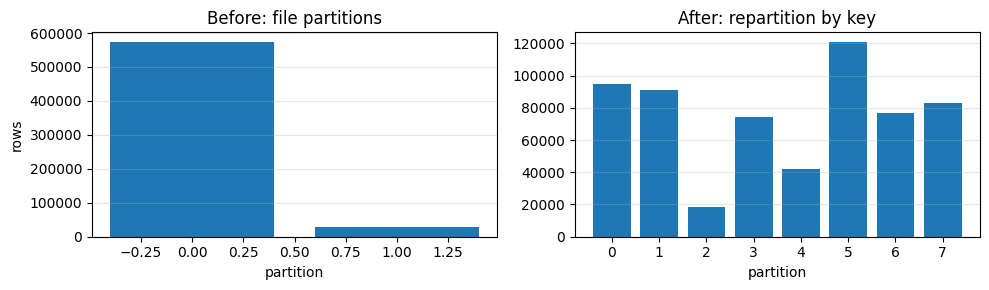

In [11]:
# Materialize and visualize partition sizes before and after a shuffle-like repartition
before = partition_row_counts(trips.select("PULocationID"))
after = partition_row_counts(trips.repartition(8, "PULocationID").select("PULocationID"))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].bar(before["partition"], before["rows"])
ax[0].set_title("Before: file partitions")
ax[0].set_xlabel("partition")
ax[0].set_ylabel("rows")
ax[0].grid(axis='y', alpha=0.3)

ax[1].bar(after["partition"], after["rows"])
ax[1].set_title("After: repartition by key")
ax[1].set_xlabel("partition")
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Tiny exercise 2 (5–10 minutes)
Write one transformation that causes a **shuffle** and prove it using `explain("formatted")`.

Hints:
- `groupBy("PULocationID").count()`
- `orderBy("total_amount")`
- `distinct()`

Your answer should include a plan snippet showing an `Exchange`.


In [ ]:
# Tiny exercise 2
# Write one transformation that causes a SHUFFLE and prove it with explain("formatted").
#
# Hints:
# - groupBy(...).count() typically shuffles
# - orderBy(...) shuffles
# - distinct() shuffles
#
# Your answer should include an Exchange node in the plan.

# TODO: define q and call q.explain("formatted")

raise NotImplementedError("Exercise 2: show a shuffle-causing transformation and its plan.")


## 7) Skew: one hot key can stall the job
We’ll create a synthetic dataset where **90% of rows share the same key**.

Then we’ll:
- visualize key frequencies,
- visualize partition imbalance after `repartition(key)`,
- apply a common mitigation: **salting**.


In [12]:
N = 1_000_000  # keep this moderate for Colab
HOT_KEY = 0
HOT_FRACTION = 0.90

base = spark.range(0, N)

skewed = (
    base
    .select(
        F.when(F.rand(42) < HOT_FRACTION, F.lit(HOT_KEY))
         .otherwise((F.rand(43) * 999 + 1).cast("int"))
         .alias("key"),
        (F.rand(99) * 100).alias("value"),
    )
)

# Tiny dimension table (1000 keys)
dim = spark.range(0, 1000).select(F.col("id").cast("int").alias("key"), F.lit("ok").alias("flag"))

print("Skewed rows:", skewed.count())


Skewed rows: 1000000


In [13]:
# Visualize top keys
key_counts = skewed.groupBy("key").count().orderBy(F.desc("count")).limit(15).toPandas()
key_counts


,key,count
0,0,899718
1,568,141
2,46,136
3,476,130
4,514,128
5,599,128
6,513,128
7,323,125
8,552,125
9,345,124


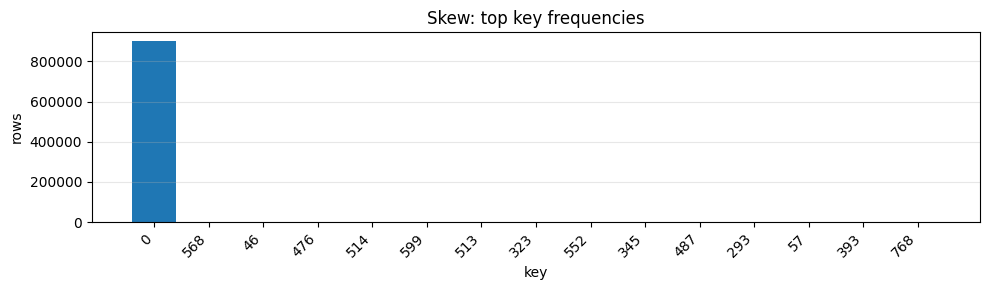

In [14]:
plt.figure(figsize=(10,3))
plt.bar(key_counts["key"].astype(str), key_counts["count"])
plt.title("Skew: top key frequencies")
plt.xlabel("key")
plt.ylabel("rows")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# Repartitioning by the skew key concentrates work into one partition.
repart_skew = skewed.repartition(8, "key")
parts = partition_row_counts(repart_skew)
parts


,partition,rows
0,0,13603
1,1,13619
2,2,12472
3,3,12736
4,4,11130
5,5,13184
6,6,12289
7,7,910967


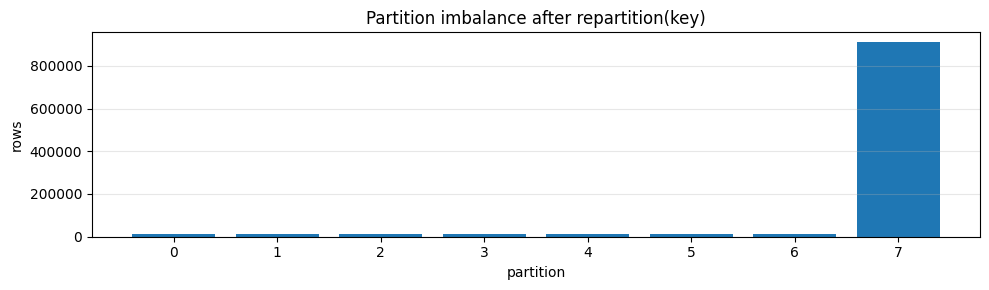

In [16]:
plt.figure(figsize=(10,3))
plt.bar(parts["partition"], parts["rows"])
plt.title("Partition imbalance after repartition(key)")
plt.xlabel("partition")
plt.ylabel("rows")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Mitigation: salting
Idea: split the hot key into multiple keys so work spreads across partitions.

Approach:
- fact table: add `salt` for hot key, random in `[0, S)`
- dimension table: duplicate the hot key row `S` times (one per salt)
- join on `(key, salt)`

Tradeoff: dimension gets bigger; logic is more complex.


In [17]:
S = 8  # number of salts

fact_salted = (
    skewed
    .withColumn(
        "salt",
        F.when(F.col("key") == HOT_KEY, (F.rand(7) * S).cast("int")).otherwise(F.lit(0)),
    )
)

# Duplicate the hot key row for all salts; keep other keys at salt=0
hot_dim = dim.where(F.col("key") == HOT_KEY).crossJoin(
    spark.range(0, S).select(F.col("id").cast("int").alias("salt"))
)
other_dim = dim.where(F.col("key") != HOT_KEY).withColumn("salt", F.lit(0))

dim_salted = hot_dim.unionByName(other_dim)

joined_salted = fact_salted.join(dim_salted, on=["key", "salt"], how="left")

parts_salted = partition_row_counts(joined_salted.repartition(8, "key", "salt"))
parts_salted


,partition,rows
0,0,236621
1,1,125085
2,2,123603
3,3,13679
4,4,125822
5,5,235842
6,6,125479
7,7,13869


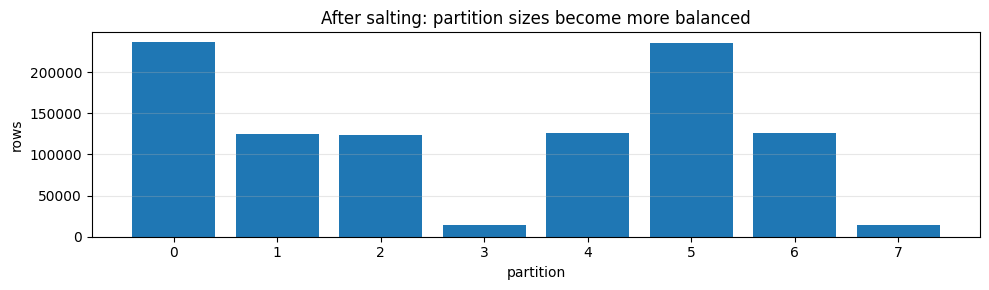

In [18]:
plt.figure(figsize=(10,3))
plt.bar(parts_salted["partition"], parts_salted["rows"])
plt.title("After salting: partition sizes become more balanced")
plt.xlabel("partition")
plt.ylabel("rows")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Tiny exercise 3 (10 minutes)
Change `S` (number of salts) and observe how partition imbalance changes.

Goal:
- make the max partition size smaller,
- without making the dimension absurdly large.

Compute and print: `max(rows) / median(rows)`.


In [ ]:
# Tiny exercise 3
# Change S (number of salts) above and observe how partition imbalance changes.
#
# Goal:
# - make the max partition smaller (more balanced)
# - without making the dimension absurdly large
#
# TODO: compute and print imbalance ratio: max(rows) / median(rows)

raise NotImplementedError("Exercise 3: compute imbalance ratio max/median for the salted join.")


## 8) Optional: Write a tiny “gold” aggregate (Parquet)
This is a small, practical artifact and also a place to discuss small-file tradeoffs.


In [19]:
GOLD_DIR = OUT_DIR / "gold_daily_by_borough"
if GOLD_DIR.exists():
    shutil.rmtree(GOLD_DIR)

# Use broadcast join for efficiency (zones is small)
trips_enriched = trips.join(F.broadcast(zones), on="PULocationID", how="left")

gold = (
    trips_enriched
    .groupBy("pickup_date", "pickup_borough")
    .agg(
        F.count("*").alias("trips"),
        F.avg("total_amount").alias("avg_total_amount"),
    )
)

gold.write.mode("overwrite").partitionBy("pickup_date").parquet(str(GOLD_DIR))

print("Wrote:", GOLD_DIR)
print("Example files:", sorted([p.as_posix() for p in GOLD_DIR.rglob('*.parquet')])[:5])


Wrote: /content/BDLab/Lab3/out/gold_daily_by_borough
Example files: ['/content/BDLab/Lab3/out/gold_daily_by_borough/pickup_date=2024-01-01/part-00000-c0c426d3-e27d-4738-af5c-598615658ad0.c000.snappy.parquet', '/content/BDLab/Lab3/out/gold_daily_by_borough/pickup_date=2024-01-02/part-00000-c0c426d3-e27d-4738-af5c-598615658ad0.c000.snappy.parquet', '/content/BDLab/Lab3/out/gold_daily_by_borough/pickup_date=2024-01-03/part-00000-c0c426d3-e27d-4738-af5c-598615658ad0.c000.snappy.parquet', '/content/BDLab/Lab3/out/gold_daily_by_borough/pickup_date=2024-01-04/part-00000-c0c426d3-e27d-4738-af5c-598615658ad0.c000.snappy.parquet', '/content/BDLab/Lab3/out/gold_daily_by_borough/pickup_date=2024-01-05/part-00000-c0c426d3-e27d-4738-af5c-598615658ad0.c000.snappy.parquet']


# Mini-assignment (end of lab)
Designed for manual grading + oral explanation.

## Assignment A — Join strategy
1. Produce a join plan that uses a shuffle join.
2. Produce a join plan that uses a broadcast join.
3. Explain when broadcast joins are a bad idea.

## Assignment B — Show a shuffle
Pick one operation that causes a shuffle and show evidence in the plan (`Exchange`).

## Assignment C — Skew mitigation
1. Create a skewed dataset (you can reuse the provided one).
2. Show partition imbalance after `repartition(key)`.
3. Apply salting (or another mitigation) and show improvement.

## Oral prompts
- What is a shuffle, operationally?
- What is skew? Why does a hot key slow the job?
- Why do broadcast joins help? What is the tradeoff?


## What you should have at the end
- A Spark notebook that can:
  - read Parquet,
  - explain joins/shuffles from plans,
  - demonstrate skew + a mitigation,
  - (optional) write a small aggregated Parquet dataset.


## References (optional)
- Spark SQL, DataFrames: https://spark.apache.org/docs/latest/sql-programming-guide.html
- Spark tuning (shuffle partitions, AQE): https://spark.apache.org/docs/latest/sql-performance-tuning.html
- Broadcast joins overview: https://spark.apache.org/docs/latest/sql-performance-tuning.html#broadcast-hash-join


## Solved Mini-Assignment (A, B, C)

These cells provide a full solution for the end-of-lab assignment:
- Assignment A: shuffle join vs broadcast join
- Assignment B: explicit shuffle evidence (`Exchange`)
- Assignment C: skew + salting mitigation with measurable improvement

Run these cells after the setup/data-loading cells above.

In [20]:
# Assignment A — Join strategy (shuffle join vs broadcast join)

# 1) Force shuffle join by disabling auto broadcast.
old_threshold = spark.conf.get("spark.sql.autoBroadcastJoinThreshold")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

a_shuffle = trips.join(zones, on="PULocationID", how="left")
print("A1) Shuffle-join plan (look for SortMergeJoin + Exchange):")
a_shuffle.explain("formatted")

# 2) Force broadcast join explicitly.
a_broadcast = trips.join(F.broadcast(zones), on="PULocationID", how="left")
print("\nA2) Broadcast-join plan (look for BroadcastHashJoin):")
a_broadcast.explain("formatted")

# Optional action to ensure plans are materializable.
shuffle_rows = a_shuffle.count()
broadcast_rows = a_broadcast.count()
print(f"\nRow counts match: {shuffle_rows == broadcast_rows} ({shuffle_rows:,} rows)")

# 3) Restore previous setting and document tradeoffs.
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", old_threshold)

print("\nA3) When broadcast joins are a bad idea:")
print("- The table being broadcast is too large for executor memory.")
print("- You join many large tables and repeated broadcasts increase memory pressure.")
print("- Data changes frequently and repeated re-broadcast costs dominate.")

A1) Shuffle-join plan (look for SortMergeJoin + Exchange):
== Physical Plan ==
AdaptiveSparkPlan (13)
+- Project (12)
   +- SortMergeJoin LeftOuter (11)
      :- Sort (5)
      :  +- Exchange (4)
      :     +- Project (3)
      :        +- Filter (2)
      :           +- Scan parquet  (1)
      +- Sort (10)
         +- Exchange (9)
            +- Project (8)
               +- Filter (7)
                  +- Scan csv  (6)


(1) Scan parquet 
Output [7]: [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, PULocationID#7, DOLocationID#8, total_amount#16]
Batched: true
Location: InMemoryFileIndex [file:/content/BDLab/Lab3/raw/yellow_tripdata_2024-01.parquet]
PushedFilters: [IsNotNull(tpep_pickup_datetime), IsNotNull(tpep_dropoff_datetime), IsNotNull(trip_distance), IsNotNull(total_amount), GreaterThanOrEqual(tpep_pickup_datetime,2024-01-01T00:00), LessThan(tpep_pickup_datetime,2024-01-08T00:00), GreaterThanOrEqual(trip_distance,0.0), GreaterThanOrEqual(t

In [21]:
# Assignment B — Show a shuffle with evidence in the plan

b_shuffle = trips.groupBy("PULocationID").count()
print("Assignment B plan (look for Exchange):")
b_shuffle.explain("formatted")

print("\nSample output:")
b_shuffle.orderBy(F.desc("count")).limit(10).toPandas()

Assignment B plan (look for Exchange):
== Physical Plan ==
AdaptiveSparkPlan (7)
+- HashAggregate (6)
   +- Exchange (5)
      +- HashAggregate (4)
         +- Project (3)
            +- Filter (2)
               +- Scan parquet  (1)


(1) Scan parquet 
Output [5]: [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, trip_distance#4, PULocationID#7, total_amount#16]
Batched: true
Location: InMemoryFileIndex [file:/content/BDLab/Lab3/raw/yellow_tripdata_2024-01.parquet]
PushedFilters: [IsNotNull(tpep_pickup_datetime), IsNotNull(tpep_dropoff_datetime), IsNotNull(trip_distance), IsNotNull(total_amount), GreaterThanOrEqual(tpep_pickup_datetime,2024-01-01T00:00), LessThan(tpep_pickup_datetime,2024-01-08T00:00), GreaterThanOrEqual(trip_distance,0.0), GreaterThanOrEqual(total_amount,0.0)]
ReadSchema: struct<tpep_pickup_datetime:timestamp_ntz,tpep_dropoff_datetime:timestamp_ntz,trip_distance:double,PULocationID:int,total_amount:double>

(2) Filter
Input [5]: [tpep_pickup_datetime#1, tpep_dropoff_

,PULocationID,count
0,132,37961
1,161,25946
2,237,24304
3,142,23433
4,236,23385
5,230,22477
6,186,22262
7,239,19572
8,138,19291
9,162,19223


In [22]:
# Assignment C — Skew mitigation with measurable improvement

# Make the cell robust if earlier skew cells were not run yet.
if "partition_row_counts" not in globals():
    def partition_row_counts(df):
        rows = df.rdd.mapPartitionsWithIndex(lambda idx, it: [(idx, sum(1 for _ in it))]).collect()
        return pd.DataFrame(rows, columns=["partition", "rows"]).sort_values("partition")

if "skewed" not in globals() or "dim" not in globals() or "HOT_KEY" not in globals():
    N = 1_000_000
    HOT_KEY = 0
    HOT_FRACTION = 0.90
    base = spark.range(0, N)
    skewed = (
        base
        .select(
            F.when(F.rand(42) < HOT_FRACTION, F.lit(HOT_KEY))
             .otherwise((F.rand(43) * 999 + 1).cast("int"))
             .alias("key"),
            (F.rand(99) * 100).alias("value"),
        )
    )
    dim = spark.range(0, 1000).select(
        F.col("id").cast("int").alias("key"),
        F.lit("ok").alias("flag"),
    )

# Baseline: skewed repartition by key.
parts_unsalted = partition_row_counts(skewed.repartition(8, "key"))
ratio_unsalted = parts_unsalted["rows"].max() / parts_unsalted["rows"].median()
print(f"Unsalted imbalance max/median: {ratio_unsalted:.2f}")

results = []
for S in [4, 8, 16]:
    fact_salted = skewed.withColumn(
        "salt",
        F.when(F.col("key") == HOT_KEY, (F.rand(7) * S).cast("int")).otherwise(F.lit(0)),
    )

    hot_dim = dim.where(F.col("key") == HOT_KEY).crossJoin(
        spark.range(0, S).select(F.col("id").cast("int").alias("salt"))
    )
    other_dim = dim.where(F.col("key") != HOT_KEY).withColumn("salt", F.lit(0))
    dim_salted = hot_dim.unionByName(other_dim)

    joined_salted = fact_salted.join(dim_salted, on=["key", "salt"], how="left")
    parts_salted = partition_row_counts(joined_salted.repartition(8, "key", "salt"))
    ratio_salted = parts_salted["rows"].max() / parts_salted["rows"].median()

    dim_growth = dim_salted.count() / dim.count()
    results.append((S, ratio_salted, dim_growth))

res_df = pd.DataFrame(results, columns=["S", "ratio_max_over_median", "dim_growth_factor"]).sort_values("S")
res_df["improvement_vs_unsalted"] = ratio_unsalted / res_df["ratio_max_over_median"]

print("\nSalting results (higher improvement is better):")
display(res_df)

best = res_df.sort_values("ratio_max_over_median").iloc[0]
print(
    f"Recommended S={int(best['S'])}: "
    f"ratio={best['ratio_max_over_median']:.2f}, "
    f"improvement={best['improvement_vs_unsalted']:.2f}x, "
    f"dimension growth={best['dim_growth_factor']:.3f}x"
)

Unsalted imbalance max/median: 70.29

Salting results (higher improvement is better):


,S,ratio_max_over_median,dim_growth_factor,improvement_vs_unsalted
0,4,1.907928,1.003,36.841359
1,8,1.888707,1.007,37.216286
2,16,1.463067,1.015,48.043377


Recommended S=16: ratio=1.46, improvement=48.04x, dimension growth=1.015x


### Oral Prompt Answers (short, grading-friendly)

- **What is a shuffle, operationally?**
  Spark redistributes rows across partitions by key (shown by `Exchange` in the physical plan), which costs network + disk I/O.

- **What is skew? Why does a hot key slow the job?**
  Skew means key frequency is very imbalanced. A hot key pushes much more data into one task/partition, so the whole stage waits on one straggler.

- **Why do broadcast joins help? What is the tradeoff?**
  Broadcast joins avoid shuffling the large table by replicating the small table to executors, usually making joins much faster. Tradeoffs: executor memory pressure, broadcast overhead, and poor behavior if the "small" side is not truly small.